In [8]:
from zipfile import ZipFile
file_name = "/archive (1).zip"

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print("Done")


Done


In [9]:
import numpy as np
import cv2
from tensorflow.keras.models import Sequential # Importing from tensorflow.keras
from tensorflow.keras.layers import Dense, Dropout, Flatten # Importing from tensorflow.keras
from tensorflow.keras.layers import Conv2D # Importing from tensorflow.keras
from tensorflow.keras.optimizers import Adam # Importing from tensorflow.keras
from tensorflow.keras.layers import MaxPooling2D # Importing from tensorflow.keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Importing from tensorflow.keras


In [10]:
train_dir = 'train'
val_dir = 'test'
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(48,48),
        batch_size=64,
        color_mode="grayscale",
        class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(48,48),
        batch_size=64,
        color_mode="grayscale",
        class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [11]:
emotion_model = Sequential()
emotion_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48,48,1)))
emotion_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))
emotion_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))
emotion_model.add(Flatten())
emotion_model.add(Dense(1024, activation='relu'))
emotion_model.add(Dropout(0.5))
emotion_model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
emotion_model.compile(loss='categorical_crossentropy',
                      optimizer=Adam(learning_rate=0.0001, decay=1e-6), # Change 'lr' to 'learning_rate'
                      metrics=['accuracy'])
emotion_model_info = emotion_model.fit( # Use fit instead of fit_generator
        train_generator,
        steps_per_epoch=28709 // 64,
        epochs=60,
        validation_data=validation_generator,
        validation_steps=7178 // 64)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


448/448 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7110 - loss: 0.7900 - val_accuracy: 0.6055 - val_loss: 1.1002
Epoch 2/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6719 - loss: 0.8368

/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.6719 - loss: 0.8368 - val_accuracy: 0.5000 - val_loss: 0.8958
Epoch 3/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.7203 - loss: 0.7681 - val_accuracy: 0.6035 - val_loss: 1.0942
Epoch 4/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 30us/step - accuracy: 0.6250 - loss: 0.9788 - val_accuracy: 0.4000 - val_loss: 1.1110
Epoch 5/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7334 - loss: 0.7352 - val_accuracy: 0.6134 - val_loss: 1.0850
Epoch 6/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6250 - loss: 0.9304 - val_accuracy: 0.7000 - val_loss: 0.8724
Epoch 7/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7400 - loss: 0.7206 - val_accuracy: 0.6133 - val_loss: 1.0822
Epoch 8/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 144us/step - accuracy: 0.6719 - loss: 0.8404 - val_accuracy: 0.6000 - val_loss: 1.7851
Epoch 9/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7481 - loss: 0.6943 - val_acc

In [38]:
#Saving the model
emotion_model.save('model.h5')

In [39]:
from keras.models import load_model
emotion_model = load_model('model.h5')

In [40]:
def emotion_analysis(emotions):
    objects = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
    y_pos = np.arange(len(objects))

    plt.bar(y_pos, emotions, align='center', alpha=0.5)
    plt.xticks(y_pos, objects)
    plt.ylabel('percentage')
    plt.title('emotion')

    plt.show()

In [41]:
#CODE for Capturing an image on Colab from here: https://colab.research.google.com/notebook#fileId=1OnUy6eFE7XhdfGfAHDCqQxpwueTOj_NO

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [50]:
take_photo()

<IPython.core.display.Javascript object>

'photo.jpg'

OpenCV(4.10.0) /io/opencv/modules/objdetect/src/cascadedetect.cpp:1689: error: (-215:Assertion failed) !empty() in function 'detectMultiScale'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


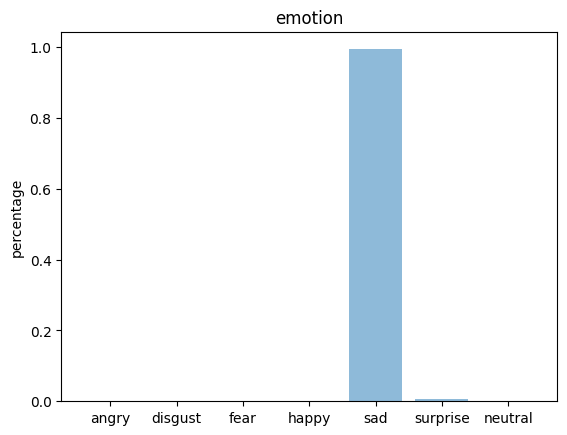

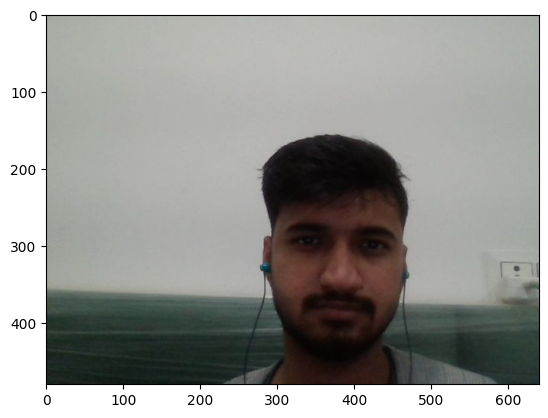

In [51]:
import cv2

def facecrop(image):
    facedata = '/content/haarcascade_frontalface_alt.xml'
    cascade = cv2.CascadeClassifier(facedata)

    img = cv2.imread(image)

    try:

        minisize = (img.shape[1],img.shape[0])
        miniframe = cv2.resize(img, minisize)

        faces = cascade.detectMultiScale(miniframe)

        for f in faces:
            x, y, w, h = [ v for v in f ]
            cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

            sub_face = img[y:y+h, x:x+w]


            cv2.imwrite('photo.jpg', sub_face)
            #print ("Writing: " + image)

    except Exception as e:
        print (e)




if __name__ == '__main__':
    facecrop('/content/photo.jpg')

#Testing a file.

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image

import numpy as np
import matplotlib.pyplot as plt


file = '/content/photo.jpg'
true_image = image.load_img(file)
img = image.load_img(file, color_mode="grayscale", target_size=(48, 48))

x = image.img_to_array(img)
x = np.expand_dims(x, axis = 0)

x /= 255

custom = emotion_model.predict(x)
emotion_analysis(custom[0])

x = np.array(x, 'float32')
x = x.reshape([48, 48]);


plt.imshow(true_image)
plt.show()